In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/investment-management/investment_management.csv


## Regression model to predict the Sales of Financial Assets

### 1. Introduction and Data Description

##### Case Study: Sales of Financial Assets
---

The dataset used is from an <b>Investment Management Firm</b>. The data consists of 2013 sales data for 1559 financial products across 10 of their branch offices in different cities</b>. The specific attributes of each financial product and office have been defined. Here are the specific columns in the dataset provided:

- Asset_Identifier: Unique product ID
- Asset_Popularity_With_Funds: Index which measures popularity of asset amongst other mutual funds and asset management companies
- Asset_Risk_Type: Whether the product is high risk or low risk (0: Low Risk, 1: High Risk)
- Asset_Marketing_Proportion_Index: The % of marketing budget spent on marketing this particular product versus other products
- Asset_Type: The category to which the product belongs
- Asset_Price: Asset Price (list price) of the product
- Office_Identifier: Unique store ID
- Office_Establishment_Year: The year in which store was established
- Office_Scale: The size of the store in terms of ground area covered
- Office_Location_Type: The type of city in which the store is located
- Office_Type: Whether the outlet is a small scale office or a larger scale one
- <b>Asset_Office_Sales</b>: Sales of the product in the particular office. This is the <b>outcome variable to be predicted</b>.
- Office_Year: Number of years which the office has been established.
- Asset: The broader category which the item belongs to (ETF, Bonds or Private Equity)



### 2. Import libraries, read data , Descriptive statistics

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

# Read data from csv into pandas dataframe
asset_sales_df = pd.read_csv('../input/investment-management/investment_management.csv')
asset_sales_df.head()

,Asset_Identifier,Asset_Popularity_With_Funds,Asset_Risk_Type,Asset_Marketing_Proportion_Index,Asset_Type,Asset_Price,Office_Identifier,Office_Establishment_Year,Office_Scale,Office_Location_Type,Office_Type,Asset_Office_Sales,Office_Year,Asset
0,FDA15,9.30,0,0.016047,4,249.8092,OFF049,1999,1,0,1,3735.1380,14,Bonds
1,DRC01,5.92,1,0.019278,14,48.2692,OFF018,2009,1,2,2,443.4228,4,ETF
2,FDN15,17.50,0,0.016760,10,141.6180,OFF049,1999,1,0,1,2097.2700,14,Bonds
3,FDX07,19.20,1,0.022911,6,182.0950,OFF010,1998,2,2,0,732.3800,15,Bonds
4,NCD19,8.93,0,0.016164,9,53.8614,OFF013,1987,0,2,1,994.7052,26,Private Equity


In [3]:
asset_sales_df.shape

(8523, 14)

In [4]:
asset_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Asset_Identifier                  8523 non-null   object 
 1   Asset_Popularity_With_Funds       8523 non-null   float64
 2   Asset_Risk_Type                   8523 non-null   int64  
 3   Asset_Marketing_Proportion_Index  8523 non-null   float64
 4   Asset_Type                        8523 non-null   int64  
 5   Asset_Price                       8523 non-null   float64
 6   Office_Identifier                 8523 non-null   object 
 7   Office_Establishment_Year         8523 non-null   int64  
 8   Office_Scale                      8523 non-null   int64  
 9   Office_Location_Type              8523 non-null   int64  
 10  Office_Type                       8523 non-null   int64  
 11  Asset_Office_Sales                8523 non-null   float64
 12  Office

In [5]:
asset_sales_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Asset_Popularity_With_Funds,8523.0,12.875418,4.645016,4.555000,8.785000,12.6500,16.850000,21.350000
Asset_Risk_Type,8523.0,0.352693,0.477836,0.000000,0.000000,0.0000,1.000000,1.000000
Asset_Marketing_Proportion_Index,8523.0,0.070749,0.050313,0.003575,0.031395,0.0581,0.098867,0.328391
Asset_Type,8523.0,7.226681,4.209990,0.000000,4.000000,6.0000,10.000000,15.000000
Asset_Price,8523.0,140.992782,62.275067,31.290000,93.826500,143.0128,185.643700,266.888400
Office_Establishment_Year,8523.0,1997.831867,8.371760,1985.000000,1987.000000,1999.0000,2004.000000,2009.000000
Office_Scale,8523.0,1.453596,0.683084,0.000000,1.000000,2.0000,2.000000,2.000000
Office_Location_Type,8523.0,1.112871,0.812757,0.000000,0.000000,1.0000,2.000000,2.000000
Office_Type,8523.0,1.201220,0.796459,0.000000,1.000000,1.0000,1.000000,3.000000
Asset_Office_Sales,8523.0,2181.288914,1706.499616,33.290000,834.247400,1794.3310,3101.296400,13086.964800


In [6]:
# Look at number of unique values each column has
asset_sales_df.nunique()

Asset_Identifier                    1559
Asset_Popularity_With_Funds          419
Asset_Risk_Type                        2
Asset_Marketing_Proportion_Index    8322
Asset_Type                            16
Asset_Price                         5938
Office_Identifier                     10
Office_Establishment_Year              9
Office_Scale                           3
Office_Location_Type                   3
Office_Type                            4
Asset_Office_Sales                  3493
Office_Year                            9
Asset                                  3
dtype: int64

In [7]:
# Checking for null values
asset_sales_df.isnull().sum()

Asset_Identifier                    0
Asset_Popularity_With_Funds         0
Asset_Risk_Type                     0
Asset_Marketing_Proportion_Index    0
Asset_Type                          0
Asset_Price                         0
Office_Identifier                   0
Office_Establishment_Year           0
Office_Scale                        0
Office_Location_Type                0
Office_Type                         0
Asset_Office_Sales                  0
Office_Year                         0
Asset                               0
dtype: int64

### 3. Exploratory Data Analysis: 

In [8]:
# Correlation heatmap
fig  = px.imshow(asset_sales_df.corr())
fig.show()

array([[<AxesSubplot:title={'center':'Asset_Popularity_With_Funds'}>,
        <AxesSubplot:title={'center':'Asset_Risk_Type'}>,
        <AxesSubplot:title={'center':'Asset_Marketing_Proportion_Index'}>],
       [<AxesSubplot:title={'center':'Asset_Type'}>,
        <AxesSubplot:title={'center':'Asset_Price'}>,
        <AxesSubplot:title={'center':'Office_Establishment_Year'}>],
       [<AxesSubplot:title={'center':'Office_Scale'}>,
        <AxesSubplot:title={'center':'Office_Location_Type'}>,
        <AxesSubplot:title={'center':'Office_Type'}>],
       [<AxesSubplot:title={'center':'Asset_Office_Sales'}>,
        <AxesSubplot:title={'center':'Office_Year'}>, <AxesSubplot:>]],
      dtype=object)

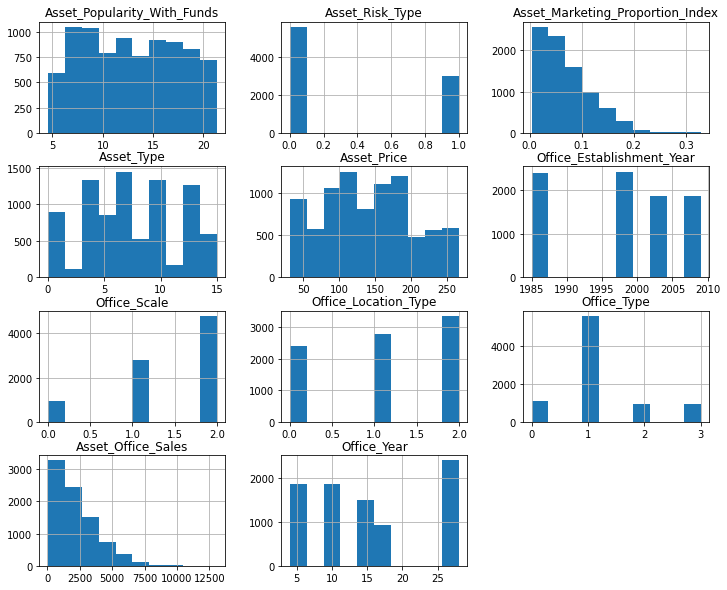

In [9]:
# Distribution of various column values
asset_sales_df.hist(figsize=(12,10))

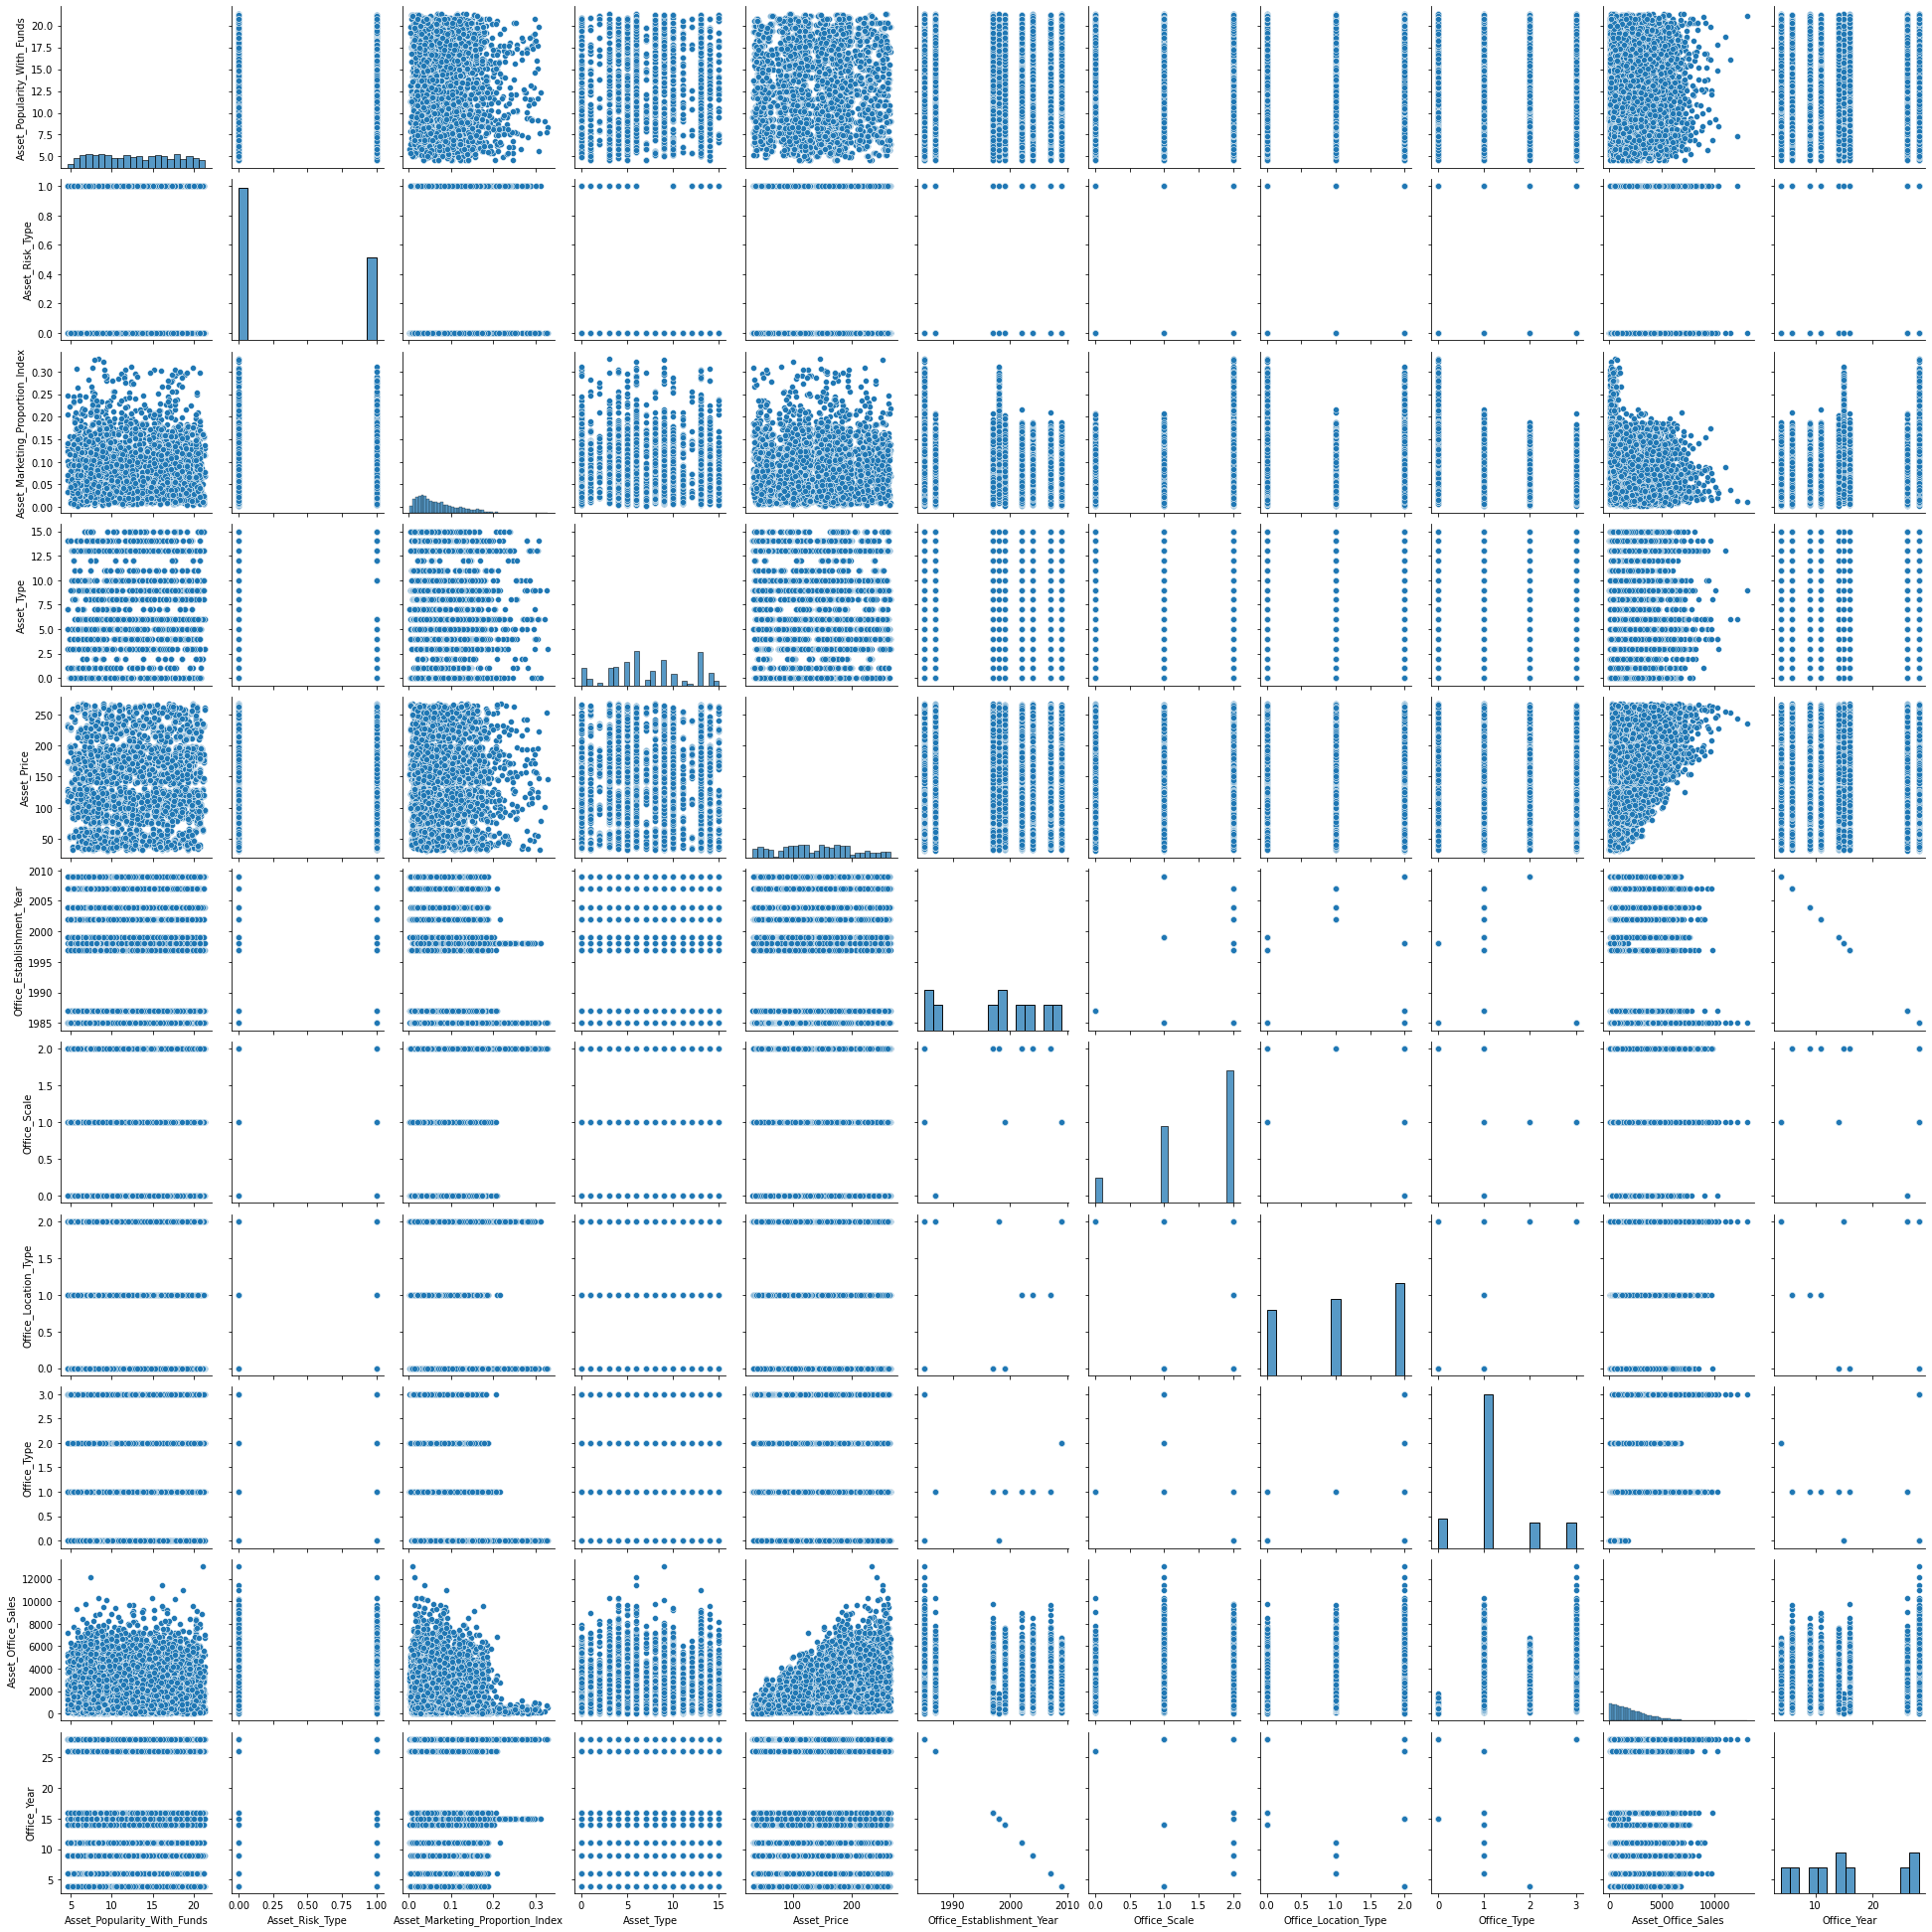

In [10]:
sns.pairplot(asset_sales_df)

In [11]:
fig = px.scatter(asset_sales_df, x="Asset_Price", y="Asset_Office_Sales", color="Office_Type",
                 trendline="ols", title="Asset Office Prices vs Asset Price")

fig.show()

'Asset_Office_Sales' has good correlation with 'Asset_Price'

In [12]:
fig=px.pie(asset_sales_df, values = 'Asset_Office_Sales', names = 'Asset', title = 'Asset Office Sales by Assets')
fig.show()

Most "Asset_Office_Sales' coming from 'Asset'  - Bonds

In [13]:
fig=px.pie(asset_sales_df, values = 'Asset_Office_Sales', names = 'Office_Type', title = 'Asset Office Sales by Office type')
fig.show()

Most "Asset_Office_Sales" coming from the office of  'Office_Type' 1, followed by 3, 2 and then 0

In [14]:
fig = px.histogram(asset_sales_df, x='Office_Establishment_Year', y='Asset_Office_Sales', color = 'Office_Identifier')
fig.update_xaxes(nticks=30)
fig.show()

Office 'OFFO27' is one of the oldest offices with  highest 'Asset_Office_Sales'  
'Offices, 'OFFO35' and 'OFFO17' are relatively recent , established in 2004 and 2007 respectively wuth  pretty good 'Asset_Office_Sales'.

'Asset_Office_Sales' from office 'OFFO19' are the lowest, it's one of the oldest office, establised in 1985.
'OFFO10' established in 1998 has the next lowest 'Asset_Office_Sales'

In [15]:
fig = px.histogram(asset_sales_df, x='Asset', y='Asset_Office_Sales', color = 'Asset_Type')
fig.update_xaxes(nticks=3)
fig.show()

Major 'Asset_Office_Sales' are from  'Asset' - 'Bonds'

'Asset_Type' - 6, 13 (Bonds), 9 (Private Equity), 5 (Bonds) are the Highest contributors to 'Asset_Office_Sales'

### 4. Feature Engineering

In [16]:
asset_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Asset_Identifier                  8523 non-null   object 
 1   Asset_Popularity_With_Funds       8523 non-null   float64
 2   Asset_Risk_Type                   8523 non-null   int64  
 3   Asset_Marketing_Proportion_Index  8523 non-null   float64
 4   Asset_Type                        8523 non-null   int64  
 5   Asset_Price                       8523 non-null   float64
 6   Office_Identifier                 8523 non-null   object 
 7   Office_Establishment_Year         8523 non-null   int64  
 8   Office_Scale                      8523 non-null   int64  
 9   Office_Location_Type              8523 non-null   int64  
 10  Office_Type                       8523 non-null   int64  
 11  Asset_Office_Sales                8523 non-null   float64
 12  Office

In [17]:
## Transform columns 'Asset' and 'Office_Identifier' into numerical form
asset_sales_df['Asset'] = asset_sales_df['Asset'].map({'ETF':0, 'Bonds': 1, 'Private Equity': 2})
asset_sales_df['Office_Identifier'] = asset_sales_df['Office_Identifier'].map({'OFF010':0, 'OFF013': 1, 'OFF017': 2, 'OFF018' :3, 
                                                                               'OFF019': 4, 'OFF027': 5, 'OFF035': 6, 'OFF045': 7, 'OFF046': 8, 'OFF049': 9})
asset_sales_df.head()

,Asset_Identifier,Asset_Popularity_With_Funds,Asset_Risk_Type,Asset_Marketing_Proportion_Index,Asset_Type,Asset_Price,Office_Identifier,Office_Establishment_Year,Office_Scale,Office_Location_Type,Office_Type,Asset_Office_Sales,Office_Year,Asset
0,FDA15,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380,14,1
1,DRC01,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228,4,0
2,FDN15,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700,14,1
3,FDX07,19.20,1,0.022911,6,182.0950,0,1998,2,2,0,732.3800,15,1
4,NCD19,8.93,0,0.016164,9,53.8614,1,1987,0,2,1,994.7052,26,2


In [18]:
# Dropping 'Asset_Identifier' column
asset_sales_df.drop('Asset_Identifier', axis = 1, inplace = True)

In [19]:
asset_sales_df.head()

,Asset_Popularity_With_Funds,Asset_Risk_Type,Asset_Marketing_Proportion_Index,Asset_Type,Asset_Price,Office_Identifier,Office_Establishment_Year,Office_Scale,Office_Location_Type,Office_Type,Asset_Office_Sales,Office_Year,Asset
0,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380,14,1
1,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228,4,0
2,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700,14,1
3,19.20,1,0.022911,6,182.0950,0,1998,2,2,0,732.3800,15,1
4,8.93,0,0.016164,9,53.8614,1,1987,0,2,1,994.7052,26,2


### 5. Feature Selection

In [20]:
## Correlation - heatmap

fig = px.imshow(asset_sales_df.corr(), text_auto= '.2f')
fig.update_layout(
            autosize=False,
    width=800,
    height=800 )
fig.show()

Most Correlation found between 'Asset_Office_sales'  (Target) and 'Asset_Price', followed by 'Office_Type', 'Office_Identifier' 

#### Feature selection using Mutual info regression

In [21]:
from sklearn.feature_selection import mutual_info_regression


X = asset_sales_df.drop('Asset_Office_Sales', axis = 1)
y= asset_sales_df['Asset_Office_Sales']

mutual_info = mutual_info_regression(X,y)
mutual_info

array([0.03430606, 0.02087088, 0.08595586, 0.05635288, 0.76299335,
       0.25134429, 0.15629157, 0.0372078 , 0.04198934, 0.26508456,
       0.15896877, 0.03294339])

In [22]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X.columns
mutual_info.sort_values(ascending=False)

Asset_Price                         0.762993
Office_Type                         0.265085
Office_Identifier                   0.251344
Office_Year                         0.158969
Office_Establishment_Year           0.156292
Asset_Marketing_Proportion_Index    0.085956
Asset_Type                          0.056353
Office_Location_Type                0.041989
Office_Scale                        0.037208
Asset_Popularity_With_Funds         0.034306
Asset                               0.032943
Asset_Risk_Type                     0.020871
dtype: float64

#### Feature Scaling

In [23]:
#Using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler


y = asset_sales_df['Asset_Office_Sales']
X = asset_sales_df.drop('Asset_Office_Sales', axis = 1)
columns = X.columns


norm = MinMaxScaler()
X_norm = norm.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns = columns)
X_norm.head()

,Asset_Popularity_With_Funds,Asset_Risk_Type,Asset_Marketing_Proportion_Index,Asset_Type,Asset_Price,Office_Identifier,Office_Establishment_Year,Office_Scale,Office_Location_Type,Office_Type,Office_Year,Asset
0,0.282525,0.0,0.038399,0.266667,0.927507,1.000000,0.583333,0.5,0.0,0.333333,0.416667,0.5
1,0.081274,1.0,0.048346,0.933333,0.072068,0.333333,1.000000,0.5,1.0,0.666667,0.000000,0.0
2,0.770765,0.0,0.040593,0.666667,0.468288,1.000000,0.583333,0.5,0.0,0.333333,0.416667,0.5
3,0.871986,1.0,0.059528,0.400000,0.640093,0.000000,0.541667,1.0,1.0,0.000000,0.458333,0.5
4,0.260494,0.0,0.038759,0.600000,0.095805,0.111111,0.083333,0.0,1.0,0.333333,0.916667,1.0


### 6. Model Building

#### Multiple Linear Regression with K-Fold Cross Validation

In [24]:
features =[ 'Asset_Price', 'Office_Type','Office_Identifier', 'Office_Year','Office_Establishment_Year','Asset_Marketing_Proportion_Index'
          ,'Asset_Type','Office_Scale']


import statistics
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

X = X_norm[features]
y = asset_sales_df['Asset_Office_Sales']

kfold = KFold(n_splits=5)
linear_reg = LinearRegression()

k_fold_RMSE = []
k_fold_r2  = []
k_fold_mae  = []

for train_index, test_index in kfold.split(X):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    linear_reg_model = LinearRegression().fit(X_train, y_train)
    y_pred = linear_reg_model.predict(X_test)
    
    RMSE = mean_squared_error(y_test, y_pred, squared=False)
    k_fold_RMSE.append(RMSE)
    
average_RMSE = statistics.mean(k_fold_RMSE)

q75, q25 = np.percentile(asset_sales_df['Asset_Office_Sales'], [75 ,25])
iqr = q75 - q25
iqr_norm_RMSE = average_RMSE/iqr


print('Average 5-fold RMSE: {:.4f}'.format(average_RMSE))

print('Normalised RMSE: {:.4f}'.format(iqr_norm_RMSE))

Average 5-fold RMSE: 1201.8164
Normalised RMSE: 0.5301
